In [1]:
# Comment: If running in Colab, uncomment the next two lines.
# from google.colab import drive
# drive.mount('/content/drive')

To use ANN for the Iris Classification using the PyTorch deep learning framework.

The aim is to classify Iris flowers into three different species based on the size of their sepals and petals.  This is a multi-class classification problem.  The three kinds of iris are shown below: Iris setosa; Iris versicolor; Iris virginica.


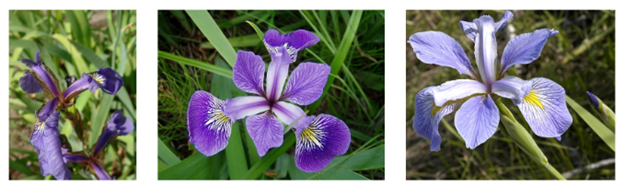

In [2]:
# Iris setosa  ;    Iris versicolor ;             Iris virginica
# To import the necessary libraries
import torch
#import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# numpy is a python library used for working with arrays. It also has functions working in linear algebra, fourier transform and matrices.
# panda is an open source data analysis and manipulation tool built on top of python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
%ls

 Volume in drive D is Data 2TB
 Volume Serial Number is 469E-A438

 Directory of D:\gpang\rebirth\Teaching\ELEC6604_2025_Sept\Course_Materials\Class04_ANN2

19/09/2025  ??10:28    <DIR>          .
16/09/2025  ??02:36    <DIR>          ..
19/09/2025  ??10:08    <DIR>          .ipynb_checkpoints
30/09/2022  ??11:09             2,206 AA-README-Class5-teaching-python.txt
20/09/2022  ??01:09           125,204 BCW_dataset.csv
05/06/2024  ??03:47            94,847 Breast-Cancer-Classification-ANN-v1.docx
20/08/2025  ??04:58            13,556 Class04_Reading_Links.docx
16/09/2025  ??03:21            43,100 Class04a_Class_Outline.pptx
19/09/2025  ??10:24         1,058,102 Class04d1_Iris_1_PyTorch.ipynb
19/09/2025  ??10:28         1,780,488 Class04d1_Iris_1_PyTorch.pptx
25/08/2025  ??04:52            73,751 Class04d2_Iris_2_sklearn.ipynb
25/08/2025  ??04:26           542,655 Class04d2_Iris_2_sklearn.pptx
25/08/2025  ??08:38            53,148 Class04d3_Iris_3_keras.ipynb
25/08/2025  ??04:27      

In [9]:
# %cd /content/drive

In [10]:
# %ls

In [11]:
# %cd /content/drive/MyDrive/ELEC6604_Sept2022/Class4_folder

In [12]:
# %ls

In [13]:
"""The Iris data set contains the four features and one label.  The four features are:
•	sepal length;
•	sepal width;
•	petal length;
•	petal width.
The label identifies the Iris species:
•	Iris setosa  (labelled 0);
•	Iris versicolor (labelled 1);
•	Iris virginica. (labelled 2).
"""

# Loading the Iris dataset
dataset = pd.read_csv('iris_dataset.csv',header = None, sep =',')

dataset.columns = ["sepal length (cm)",
                   "sepal width (cm)",
                   "petal length (cm)",
                   "petal width (cm)",
                   "species"]

dataset.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
# Next is to change the species data to numeric values.
mappings = {
   "Iris-setosa": 0,
   "Iris-versicolor": 1,
   "Iris-virginica": 2
}

"""a lambda function is a small anonymous function """

dataset["species"] = dataset["species"].apply(lambda x: mappings[x])

dataset.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


The ANN architecture is converted to a three-output neural network.

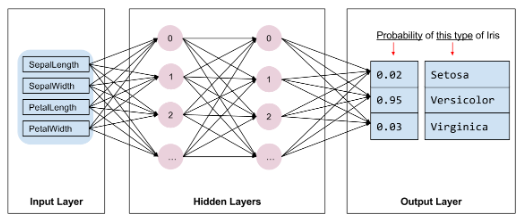

In the example above, the output indicates a 95% probability that it is an Iris Versicolor.

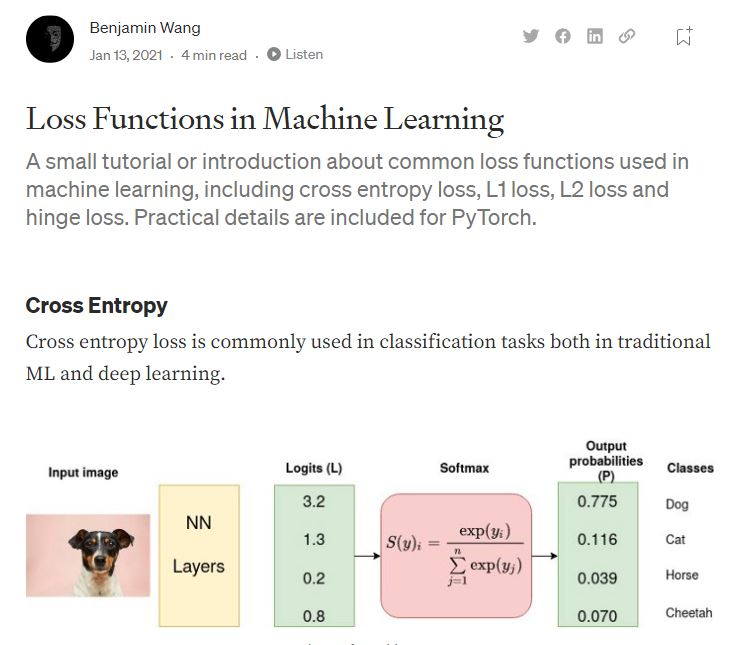

Logits:
The vector of raw (non-normalized) predictions that a classification model generates, which is ordinarily then passed to a normalization function. If the model is solving a multi-class classification problem, logits typically become an input to the softmax function. The softmax function then generates a vector of (normalized) probabilities with one value for each possible class.

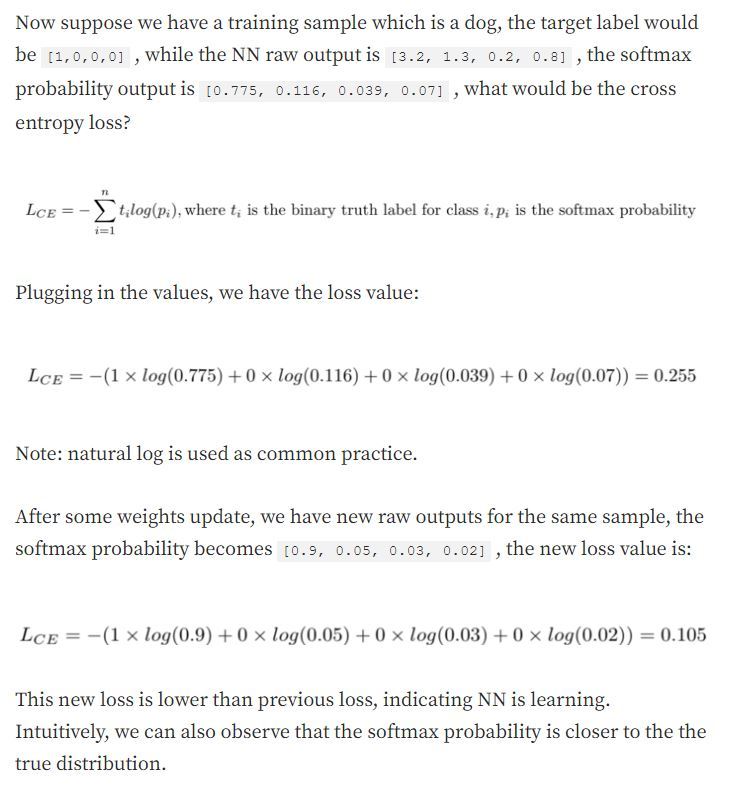

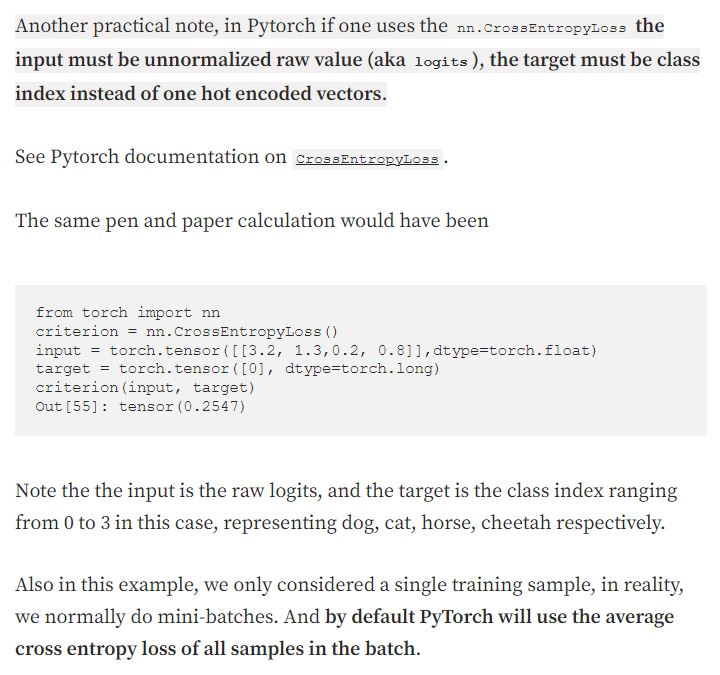

In [17]:
X = dataset.drop("species",axis=1).values
y = dataset["species"].values
# The X values are the first 4 columns of the dataset
# The y value is the last column called species

print('Dimension of X is ',X.shape)
print('Dimension of y is ',y.shape)

# Next, we load our dataset and split it into training/test sets by ratio 80/20.
# Note:  150 pieces of data: 120 for training, 30 for testing
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)

print('Dimension of X_train (A) is ',X_train.shape)
X_train = torch.FloatTensor(X_train)
print('Dimension of X_train (B) is ',X_train.shape)
print('Dimension of y_train is ',y_train.shape)
print('y_train: ',y_train)

X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

Dimension of X is  (150, 4)
Dimension of y is  (150,)
Dimension of X_train (A) is  (120, 4)
Dimension of X_train (B) is  torch.Size([120, 4])
Dimension of y_train is  (120,)
y_train:  [1 0 0 0 2 2 2 1 1 2 0 0 2 1 1 1 2 2 1 2 0 1 0 0 2 0 1 0 1 1 0 2 1 0 0 0 2
 2 0 1 0 1 0 1 0 1 1 0 2 0 2 2 0 0 2 0 2 0 2 2 2 1 0 1 2 0 1 2 0 2 2 1 0 2
 2 1 2 1 1 1 1 1 0 1 2 1 0 2 1 2 1 1 2 2 1 1 0 1 1 2 0 1 1 2 0 2 0 0 0 1 2
 1 1 0 1 1 1 2 0 0]


In [18]:
# Creating the ANN Model
""" Our model will have following structure:
Fully Connected Layer1:  4 input features, 25 output features
Fully Connected Layer2:  25 input features, 30 output features
Output Layer:            30 input features , 3 output features
Here we choose hidden layers’ neurons as arbitrary (25 and 30 respectively).
We will use ReLU (rectified linear unit) as activation function.
"""

class Model(nn.Module):
    def __init__(self, input_features=4, hidden_layer1=25, hidden_layer2=30, output_features=3):
        super().__init__()
        self.fc1 = nn.Linear(input_features,hidden_layer1)
        self.fc2 = nn.Linear(hidden_layer1, hidden_layer2)
        self.out = nn.Linear(hidden_layer2, output_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

model = Model()
print(model)

Model(
  (fc1): Linear(in_features=4, out_features=25, bias=True)
  (fc2): Linear(in_features=25, out_features=30, bias=True)
  (out): Linear(in_features=30, out_features=3, bias=True)
)


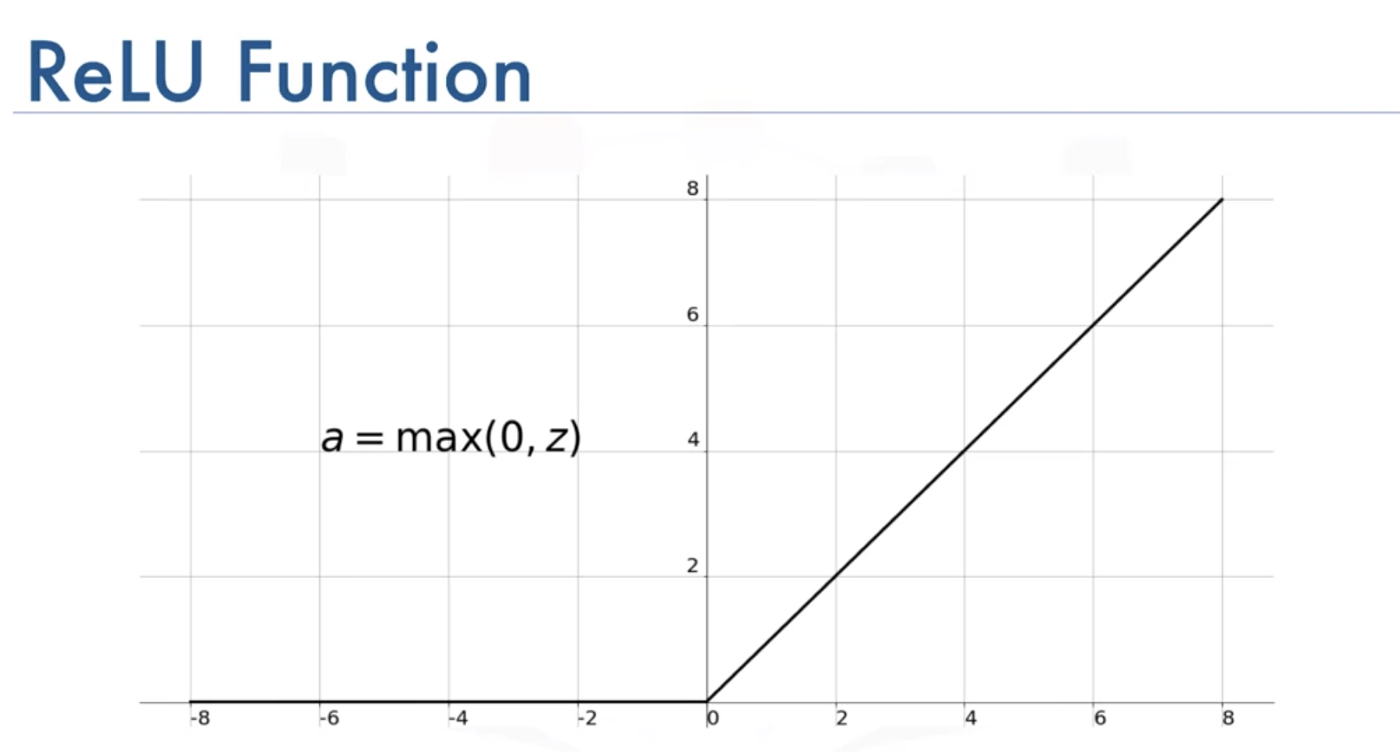

Setting hyper-parameters:
We start with learning rate 0.01 then we can work on and see its effect on the training process. Also we will use Cross Entropy and Adam (adaptive moment estimation) optimizer.


The Adam optimization algorithm computes individual adaptive learning rates for different network parameters (weights). The Cross Entropy loss function is a popular alternative to the MSE (mean squared error) for measuring the performance of the model during training.  Some researchers have shown that it can lead to faster training.

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


# Training
epochs = 100
losses = []
losses_tmp = []

for i in range(epochs):
    y_pred = model.forward(X_train)
    loss = criterion(y_pred, y_train)
    losses.append(loss)
    losses_tmp.append(loss.item())
    print(f'epoch: {i:2}  loss: {loss.item():10.8f}')
    #print('   X_train.shape ', X_train.shape , 'y_pred.shape ', y_pred.shape)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

epoch:  0  loss: 1.12904501
epoch:  1  loss: 1.04621112
epoch:  2  loss: 1.01884043
epoch:  3  loss: 0.99678123
epoch:  4  loss: 0.96842426
epoch:  5  loss: 0.93086529
epoch:  6  loss: 0.88882476
epoch:  7  loss: 0.84203964
epoch:  8  loss: 0.79233766
epoch:  9  loss: 0.74345553
epoch: 10  loss: 0.69913226
epoch: 11  loss: 0.65315688
epoch: 12  loss: 0.60569066
epoch: 13  loss: 0.56011623
epoch: 14  loss: 0.51678568
epoch: 15  loss: 0.47637308
epoch: 16  loss: 0.44116029
epoch: 17  loss: 0.41113976
epoch: 18  loss: 0.38340890
epoch: 19  loss: 0.35831231
epoch: 20  loss: 0.33691838
epoch: 21  loss: 0.31543407
epoch: 22  loss: 0.29439884
epoch: 23  loss: 0.27386367
epoch: 24  loss: 0.25153708
epoch: 25  loss: 0.23367567
epoch: 26  loss: 0.21501277
epoch: 27  loss: 0.19910623
epoch: 28  loss: 0.18288058
epoch: 29  loss: 0.16902559
epoch: 30  loss: 0.15527984
epoch: 31  loss: 0.14386187
epoch: 32  loss: 0.13248788
epoch: 33  loss: 0.12359879
epoch: 34  loss: 0.11459652
epoch: 35  loss: 0.1

In [20]:
"""Note that in the main loop:
y_pred = model.forward(X_train)

is forward propagation with input X_train ([120,4]) and output is y_pred ([120,3])

loss = criterion(y_pred, y_train)

is calculating the difference between the y_train ([120]) and y_pred ([120,30]).

optimizer.zero_grad() is used to clear up the gradient values in the previous epoch.

loss.backward() is used to backpropagate to calculate all the gradient values.

optimizer.step() is used to carry out gradient descent. """


'Note that in the main loop:\ny_pred = model.forward(X_train)\n\nis forward propagation with input X_train ([120,4]) and output is y_pred ([120,3])\n\nloss = criterion(y_pred, y_train)\n\nis calculating the difference between the y_train ([120]) and y_pred ([120,30]).\n\noptimizer.zero_grad() is used to clear up the gradient values in the previous epoch.\n\nloss.backward() is used to backpropagate to calculate all the gradient values.\n\noptimizer.step() is used to carry out gradient descent. '

In [21]:
print('len(losses) = ',len(losses))
print(epochs)
x_values=np.linspace(start=1,stop=100,num=100)
print(x_values)
#print(losses)
print(losses_tmp)



len(losses) =  100
100
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100.]
[1.129045009613037, 1.0462111234664917, 1.0188404321670532, 0.9967812299728394, 0.9684242606163025, 0.9308652877807617, 0.8888247609138489, 0.8420396447181702, 0.7923376560211182, 0.7434555292129517, 0.6991322636604309, 0.6531568765640259, 0.6056906580924988, 0.5601162314414978, 0.5167856812477112, 0.4763730764389038, 0.44116029143333435, 0.41113975644111633, 0.38340890407562256, 0.35831230878829956, 0.3369183838367462, 0.315434068441391, 0.29439884424209595, 0.27

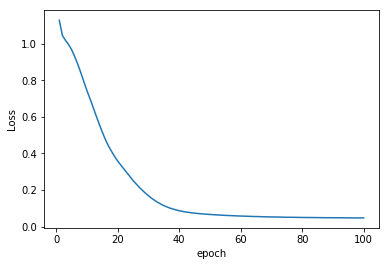

preds          = [0, 2, 0, 0, 2, 1, 0, 0, 2, 0, 1, 2, 1, 2, 2, 2, 2, 1, 2, 0, 1, 2, 2, 0, 0, 2, 2, 2, 0, 0]
y_test =  tensor([0, 2, 0, 0, 2, 1, 0, 0, 2, 0, 1, 1, 1, 2, 2, 2, 2, 1, 2, 0, 1, 2, 2, 0,
        0, 2, 2, 2, 0, 0])


In [23]:
# To visualize the training results
plt.plot(x_values, losses_tmp)
plt.ylabel('Loss')
plt.xlabel('epoch');
plt.show()  # to show the Figure


#Validating and testing the model
# X_test.shape is [30,4]
preds = []
with torch.no_grad():
    for val in X_test:
        y_hat = model.forward(val)
        preds.append(y_hat.argmax().item())

print('preds          =',preds)
print('y_test = ',y_test)

In [24]:
""" EXPLANATIONS:
X_test is [30,4]   y_test is [30,1]
input   (val) is  [4]  i.e. four inputs
output (y_hat) is [3]  i.e. three outputs
y_hat.argmax().item()  is to get the argument which is the largest.
Example: we use the last item in the X_test, and provide as input to the trained ANN.
The three outputs are given as y_ANN.
The last output item (11.6706) is the largest and the answer is index  2,
which is the same as y_test[29]  (Iris-virginica).
"""

' EXPLANATIONS:\nX_test is [30,4]   y_test is [30,1]\ninput   (val) is  [4]  i.e. four inputs\noutput (y_hat) is [3]  i.e. three outputs\ny_hat.argmax().item()  is to get the argument which is the largest.\nExample: we use the last item in the X_test, and provide as input to the trained ANN.\nThe three outputs are given as y_ANN.\nThe last output item (11.6706) is the largest and the answer is index  2,\nwhich is the same as y_test[29]  (Iris-virginica).\n'

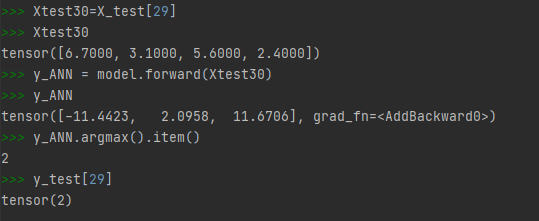

In [25]:
""" Testing the model with unseen data
unknown_iris = torch.tensor([4.0,3.3,1.7,0.5])

with torch.no_grad():
    print(model(unknown_iris))
    print()
    print(labels[model(unknown_iris).argmax()])

tensor([ 12.0534, 7.1283, -17.9192])
# 12.0534 is the largest value, 1st class is the answer
Iris-setosa
"""


' Testing the model with unseen data\nunknown_iris = torch.tensor([4.0,3.3,1.7,0.5])\n\nwith torch.no_grad():\n    print(model(unknown_iris))\n    print()\n    print(labels[model(unknown_iris).argmax()])\n\ntensor([ 12.0534, 7.1283, -17.9192])\n# 12.0534 is the largest value, 1st class is the answer\nIris-setosa\n'

In [26]:
""" A summary of this demo:
- Import the relevant libraries and Load the dataset
- Create a model
- Training the model
- Testing the model with unseen data

References:
[1] https://medium.com/@ozgur.ersoz3/iris-flowers-classification-with-pytorch-cd80c8aeeb2c
[2] https://pytorch.org/docs/stable/index.html
[3] https://towardsdatascience.com/your-first-neural-network-in-pytorch-725631ae0fc
[4] https://www.udemy.com/course/pytorch-for-deep-learning-with-python-bootcamp/

"""


' A summary of this demo:\n- Import the relevant libraries and Load the dataset\n- Create a model\n- Training the model\n- Testing the model with unseen data\n\nReferences:\n[1] https://medium.com/@ozgur.ersoz3/iris-flowers-classification-with-pytorch-cd80c8aeeb2c\n[2] https://pytorch.org/docs/stable/index.html\n[3] https://towardsdatascience.com/your-first-neural-network-in-pytorch-725631ae0fc\n[4] https://www.udemy.com/course/pytorch-for-deep-learning-with-python-bootcamp/\n\n'